# Notebook 6: Model Improvement and Hyperparameter Tuning

## 1. Objective

In this notebook, we improve the baseline machine learning models created in Notebook 5.

The main goal is to optimize model performance using hyperparameter tuning, cross-validation, feature selection, and advanced evaluation.

We will focus mainly on improving the Random Forest model because it performed well as a baseline and can capture non-linear relationships in glucose prediction.

## What this notebook includes

- Loading modeling-ready data
- Loading baseline results
- Train-test splitting
- Cross-validation
- GridSearchCV
- RandomizedSearchCV
- Random Forest optimization
- Overfitting analysis
- Feature selection improvement
- Tuned model evaluation
- Feature importance refinement
- SHAP / interpretability basics
- Saving tuned model outputs
- GitHub-ready summary

# 2. Import Libraries

In [2]:
# Import Core libraries
import os
import pickle
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# Model selection and tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold
)

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Feature selection
from sklearn.feature_selection import SelectFromModel

# Ignore warnings for cleaner notebook output
warnings.filterwarnings("ignore")

### Why this step is needed

We import all libraries needed for data loading, model training, hyperparameter tuning, evaluation, visualization, and saving outputs.

### Consequences if skipped

The notebook will fail when using functions such as `GridSearchCV`, `RandomizedSearchCV`, model evaluation metrics, or visualization tools.

# 3. Universal Chart Styling Setup

In [3]:
# Universal chart styling setup

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="husl"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.titlesize"] = 18

print("Universal chart styling applied successfully.")

Universal chart styling applied successfully.


### Why this step is needed

This ensures that all charts in the notebook follow a consistent visual style.

### Consequences if skipped

Charts may look inconsistent, harder to compare, and less professional for GitHub review.

# 4. Define File Paths

In [4]:
# Define project paths

BASE_DIR = os.path.dirname(os.getcwd())

DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

# Create folders if they do not already exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

modeling_data_path = os.path.join(DATA_DIR, "modeling_ready_dataset.csv")
feature_list_path = os.path.join(DATA_DIR, "modeling_feature_list.csv")
baseline_results_path = os.path.join(REPORTS_DIR, "baseline_model_results.csv")

print("Paths defined successfully.")

Paths defined successfully.


### Why this step is needed

Using clear file paths keeps the project organized and makes the notebook easier to reproduce.

### Consequences if skipped

Files may be saved in random locations, making the project harder to manage and review.

# 5. Load Modeling Dataset and Feature List

In [5]:
# Load modeling-ready dataset
df = pd.read_csv(modeling_data_path)

# Load feature list
feature_list_df = pd.read_csv(feature_list_path)

# Extract feature names
features = feature_list_df["feature_name"].tolist()

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Number of features:", len(features))

Dataset loaded successfully.
Dataset shape: (309242, 21)
Number of features: 14


In [6]:
df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,...,hour,day,day_of_week,date,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
0,2018-06-13 19:10:00,312.0,10.1430,91.339623,48.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,313.0,324.0,332.0,318.500000,320.428571
1,2018-06-13 19:15:00,293.0,6.8425,89.893443,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,312.0,306.0,326.0,313.000000,317.000000
2,2018-06-13 19:20:00,303.0,5.2325,89.352941,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,293.0,313.0,330.0,308.500000,315.444444
3,2018-06-13 19:25:00,293.0,8.0500,89.778761,77.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,303.0,312.0,324.0,303.333333,313.200000
4,2018-06-13 19:30:00,271.0,17.7905,104.536232,124.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,...,19,13,2,2018-06-13,evening,293.0,293.0,306.0,297.500000,309.363636


In [7]:
features

['calories',
 'heart_rate',
 'steps',
 'basal_rate',
 'bolus_volume_delivered',
 'carb_input',
 'hour',
 'day',
 'day_of_week',
 'glucose_lag_1',
 'glucose_lag_3',
 'glucose_lag_6',
 'glucose_rolling_30min',
 'glucose_rolling_1hr']

### Why this step is needed

We use the cleaned and modeling-ready dataset from previous notebooks instead of repeating preprocessing.

### Consequences if skipped

The model may be trained on raw or inconsistent data, which can lead to unreliable results.

# 6. Define Target and Features

In [8]:
# Define target variable
target = "glucose"

# Create X and y
X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)# Define target variable
target = "glucose"

# Create X and y
X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (309242, 14)
Target shape: (309242,)
Feature matrix shape: (309242, 14)
Target shape: (309242,)


### Why this step is needed

GridSearchCV tests every combination of selected hyperparameters to find the best model configuration.

### Consequences if skipped

We may continue using default model settings that are not optimal for this dataset.

# 7. Train-Test Split

In [9]:
# Random train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (247393, 14)
Testing features shape: (61849, 14)
Training target shape: (247393,)
Testing target shape: (61849,)


### Why this step is needed

We separate training and testing data to evaluate how well the tuned model performs on unseen data.

### Consequences if skipped

The model may be evaluated on the same data it was trained on, giving overly optimistic results.

# 8. Create Evaluation Function

In [10]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate regression model performance.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### Why this step is needed

This function avoids repeating evaluation code for every model.

### Consequences if skipped

Evaluation code becomes repetitive and increases the chance of mistakes.

# 9. Load Baseline Results

In [11]:
# Load baseline model results

baseline_results = pd.read_csv(baseline_results_path)

baseline_results

,model,split_strategy,MAE,RMSE,R2
0,Random Forest Regression,Chronological Split,1.231959,2.210512,0.997142
1,Decision Tree Regression,Chronological Split,1.661097,2.652242,0.995886
2,Linear Regression,Chronological Split,1.808094,2.717967,0.995679
3,Random Forest Regression,Random Split,1.682843,4.188599,0.994611
4,Decision Tree Regression,Random Split,2.119275,4.456281,0.993901
5,Linear Regression,Random Split,2.178058,4.644898,0.993373
6,Random Forest Regression,Patient-Level Split,1.719092,5.058404,0.989678
7,Decision Tree Regression,Patient-Level Split,2.162416,5.257784,0.988848
8,Linear Regression,Patient-Level Split,1.677873,6.303409,0.983971


### Why this step is needed

Baseline results help us compare whether tuning actually improved the model.

### Consequences if skipped

We cannot clearly prove whether the tuned model is better than the baseline model.

# 10. Baseline Random Forest Recheck

In [12]:
# Train baseline Random Forest again for comparison

baseline_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

baseline_rf_train_pred = baseline_rf.predict(X_train)
baseline_rf_test_pred = baseline_rf.predict(X_test)

baseline_train_eval = evaluate_model(
    "Baseline Random Forest - Train",
    y_train,
    baseline_rf_train_pred
)

baseline_test_eval = evaluate_model(
    "Baseline Random Forest - Test",
    y_test,
    baseline_rf_test_pred
)

pd.DataFrame([baseline_train_eval, baseline_test_eval])

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593


### Why this step is needed

Before tuning, we confirm the baseline Random Forest performance on the same split used in this notebook.

### Consequences if skipped

The comparison between baseline and tuned model may not be fair.

# 11. Cross-Validation on Baseline Random Forest

In [13]:
# Cross-validation setup

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    baseline_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:", cv_rmse_scores)
print("Mean CV RMSE:", cv_rmse_scores.mean())
print("Standard deviation CV RMSE:", cv_rmse_scores.std())

Cross-validation RMSE scores: [3.88836651 3.89075485 3.88127104 4.00331745 3.51008714]
Mean CV RMSE: 3.8347594006877292
Standard deviation CV RMSE: 0.16852088082175357


### Why this step is needed

Cross-validation gives a more stable estimate of model performance by testing the model across multiple data splits.

### Consequences if skipped

The model may look good only because of one lucky train-test split.

# 12. GridSearchCV for Random Forest

In [14]:
# Define smaller parameter grid for GridSearchCV

param_grid = {
    "n_estimators": [100],
    "max_depth": [10, None],
    "min_samples_split": [2],
    "min_samples_leaf": [1, 2]
}

grid_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=grid_rf,
    param_grid=param_grid,
    cv=2,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'min_samples_leaf': [1, 2], 'min_samples_split': [2], 'n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [15]:
print("Best GridSearchCV parameters:")
print(grid_search.best_params_)

print("Best GridSearchCV RMSE:")
print(-grid_search.best_score_)

Best GridSearchCV parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GridSearchCV RMSE:
3.887765187794439


### Why this step is needed

GridSearchCV tests every combination of selected hyperparameters to find the best model configuration.

### Consequences if skipped

We may continue using default model settings that are not optimal for this dataset.

# 13. Evaluate GridSearchCV Model

In [16]:
# Best grid search model
best_grid_rf = grid_search.best_estimator_

# Predictions
grid_train_pred = best_grid_rf.predict(X_train)
grid_test_pred = best_grid_rf.predict(X_test)

# Evaluation
grid_train_eval = evaluate_model(
    "GridSearchCV Random Forest - Train",
    y_train,
    grid_train_pred
)

grid_test_eval = evaluate_model(
    "GridSearchCV Random Forest - Test",
    y_test,
    grid_test_pred
)

grid_results_df = pd.DataFrame([grid_train_eval, grid_test_eval])
grid_results_df

,model,MAE,RMSE,R2
0,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
1,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593


### Why this step is needed

After tuning, we need to evaluate the tuned model on both training and testing data.

### Consequences if skipped

We would know the best parameters but not whether they actually improved prediction performance.

# 14. RandomizedSearchCV for Random Forest

In [17]:
# Smaller parameter distribution for portfolio-friendly tuning

param_random = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

In [18]:
random_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=random_rf,
    param_distributions=param_random,
    n_iter=8,
    cv=2,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 2 folds for each of 8 candidates, totalling 16 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

Due to the relatively large dataset size, a smaller and computationally efficient hyperparameter search space was selected to balance model optimization and runtime performance.

This approach demonstrates practical model tuning strategies commonly used in real-world machine learning workflows.

In [19]:
print("Best RandomizedSearchCV parameters:")
print(random_search.best_params_)

print("Best RandomizedSearchCV RMSE:")
print(-random_search.best_score_)

Best RandomizedSearchCV parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best RandomizedSearchCV RMSE:
3.7984690377833212


### Why this step is needed

RandomizedSearchCV tests a random sample of many hyperparameter combinations. It is faster than testing every possible combination.

### Consequences if skipped

We may miss better parameter combinations, especially when the search space is large.

# 15. Evaluate RandomizedSearchCV Model

In [20]:
# Best randomized search model
best_random_rf = random_search.best_estimator_

# Predictions
random_train_pred = best_random_rf.predict(X_train)
random_test_pred = best_random_rf.predict(X_test)

# Evaluation
random_train_eval = evaluate_model(
    "RandomizedSearchCV Random Forest - Train",
    y_train,
    random_train_pred
)

random_test_eval = evaluate_model(
    "RandomizedSearchCV Random Forest - Test",
    y_test,
    random_test_pred
)

random_results_df = pd.DataFrame([random_train_eval, random_test_eval])
random_results_df

,model,MAE,RMSE,R2
0,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199
1,RandomizedSearchCV Random Forest - Test,1.731706,3.649768,0.995909


### Why this step is needed

This allows us to compare RandomizedSearchCV performance against GridSearchCV and the baseline model.

### Consequences if skipped

We cannot decide which tuning method produced the strongest model.

# 16. Compare Baseline, GridSearchCV, and RandomizedSearchCV

In [21]:
# Combine model results

comparison_results = pd.DataFrame([
    baseline_train_eval,
    baseline_test_eval,
    grid_train_eval,
    grid_test_eval,
    random_train_eval,
    random_test_eval
])

comparison_results

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593
2,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
3,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593
4,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199
5,RandomizedSearchCV Random Forest - Test,1.731706,3.649768,0.995909


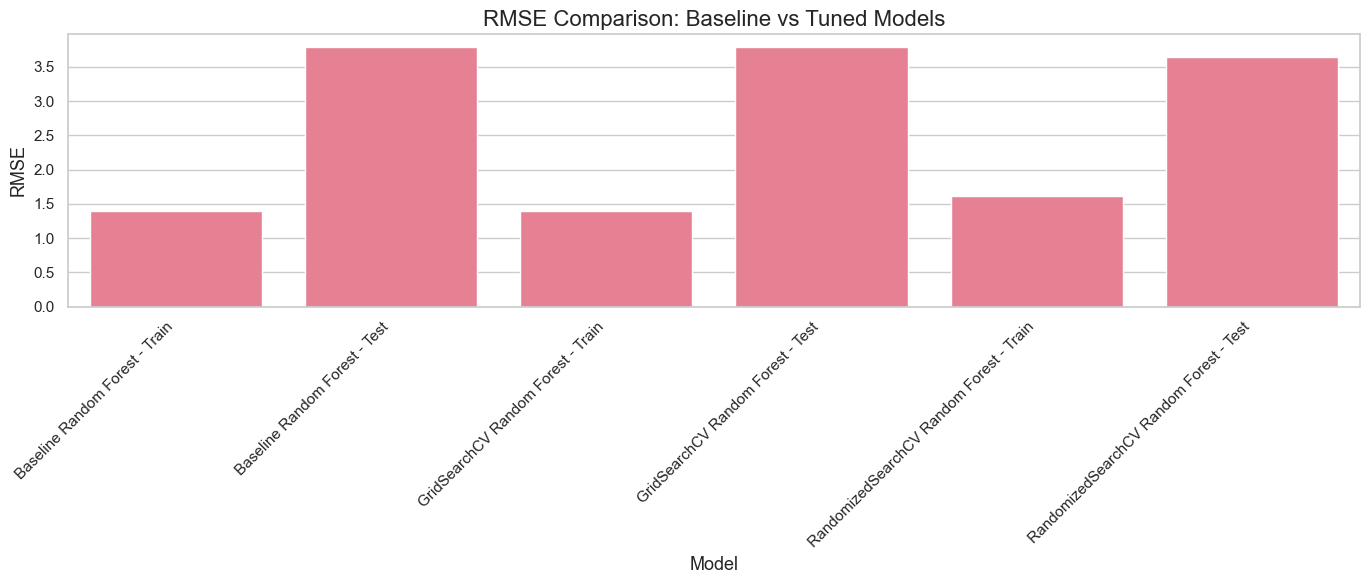

In [22]:
# Plot RMSE comparison

plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_results,
    x="model",
    y="RMSE"
)

plt.title("RMSE Comparison: Baseline vs Tuned Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

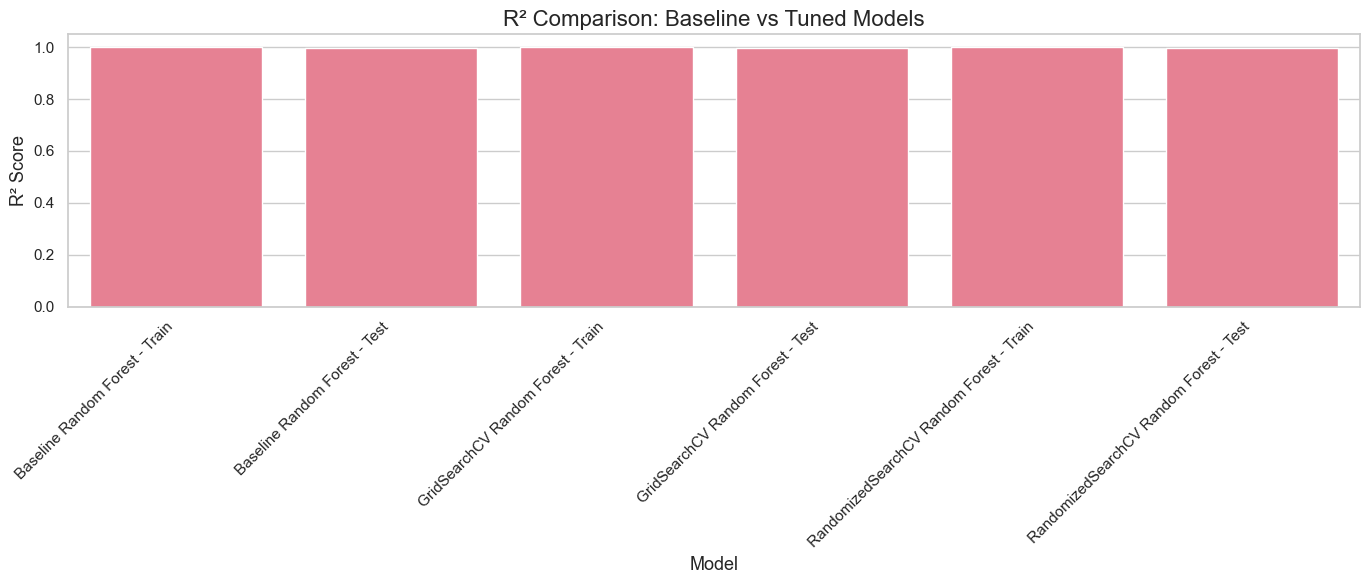

In [23]:
# Plot R2 comparison

plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_results,
    x="model",
    y="R2"
)

plt.title("R² Comparison: Baseline vs Tuned Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Why this step is needed

Visual comparisons make it easier to understand which model performs best.

### Consequences if skipped

It becomes harder to communicate model improvement clearly in the notebook and GitHub project.

# 17. Overfitting Analysis

In [24]:
# Calculate train-test performance gap

overfitting_analysis = comparison_results.copy()

overfitting_analysis

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593
2,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
3,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593
4,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199
5,RandomizedSearchCV Random Forest - Test,1.731706,3.649768,0.995909


In [25]:
# Separate train and test results manually

overfit_summary = pd.DataFrame({
    "model_type": [
        "Baseline Random Forest",
        "GridSearchCV Random Forest",
        "RandomizedSearchCV Random Forest"
    ],
    "train_RMSE": [
        baseline_train_eval["RMSE"],
        grid_train_eval["RMSE"],
        random_train_eval["RMSE"]
    ],
    "test_RMSE": [
        baseline_test_eval["RMSE"],
        grid_test_eval["RMSE"],
        random_test_eval["RMSE"]
    ],
    "train_R2": [
        baseline_train_eval["R2"],
        grid_train_eval["R2"],
        random_train_eval["R2"]
    ],
    "test_R2": [
        baseline_test_eval["R2"],
        grid_test_eval["R2"],
        random_test_eval["R2"]
    ]
})

overfit_summary["RMSE_gap"] = overfit_summary["test_RMSE"] - overfit_summary["train_RMSE"]
overfit_summary["R2_gap"] = overfit_summary["train_R2"] - overfit_summary["test_R2"]

overfit_summary

,model_type,train_RMSE,test_RMSE,train_R2,test_R2,RMSE_gap,R2_gap
0,Baseline Random Forest,1.388946,3.787735,0.999408,0.995593,2.398790,0.003815
1,GridSearchCV Random Forest,1.388946,3.787735,0.999408,0.995593,2.398790,0.003815
2,RandomizedSearchCV Random Forest,1.615871,3.649768,0.999199,0.995909,2.033898,0.003290


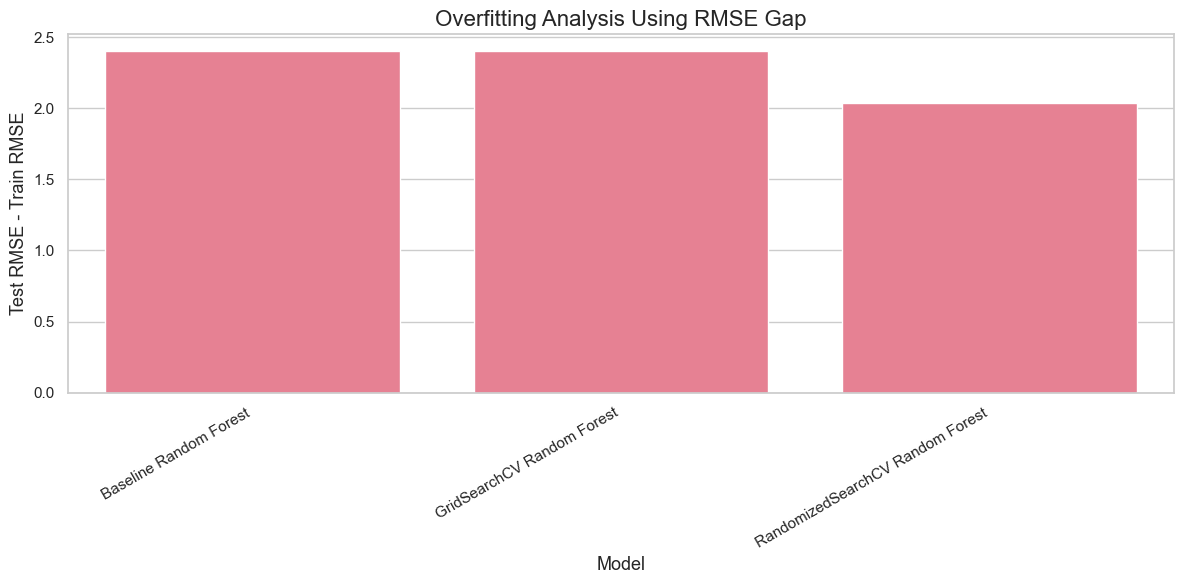

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=overfit_summary,
    x="model_type",
    y="RMSE_gap"
)

plt.title("Overfitting Analysis Using RMSE Gap")
plt.xlabel("Model")
plt.ylabel("Test RMSE - Train RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Why this step is needed

Overfitting happens when a model performs very well on training data but poorly on test data.

### Consequences if skipped

We may choose a model that memorizes training data but does not generalize well to new patients or future glucose readings.

# 18. Select Best Tuned Model

In [27]:
# Select best model based on lowest test RMSE

test_results = comparison_results[
    comparison_results["model"].str.contains("Test")
].copy()

best_model_row = test_results.sort_values("RMSE").iloc[0]

best_model_row

model    RandomizedSearchCV Random Forest - Test
MAE                                     1.731706
RMSE                                    3.649768
R2                                      0.995909
Name: 5, dtype: object

In [28]:
# Assign final tuned model

if "RandomizedSearchCV" in best_model_row["model"]:
    final_tuned_model = best_random_rf
    final_model_name = "RandomizedSearchCV Random Forest"
elif "GridSearchCV" in best_model_row["model"]:
    final_tuned_model = best_grid_rf
    final_model_name = "GridSearchCV Random Forest"
else:
    final_tuned_model = baseline_rf
    final_model_name = "Baseline Random Forest"

print("Selected final model:", final_model_name)

Selected final model: RandomizedSearchCV Random Forest


### Why this step is needed

We choose the strongest model using objective performance metrics instead of guessing.

### Consequences if skipped

The final model selection may be unclear or subjective.

# 19. Feature Importance from Tuned Model

In [29]:
# Extract feature importance

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": final_tuned_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
9,glucose_lag_1,0.327931
12,glucose_rolling_30min,0.223430
10,glucose_lag_3,0.197195
13,glucose_rolling_1hr,0.152312
11,glucose_lag_6,0.091655
1,heart_rate,0.002251
0,calories,0.001871
3,basal_rate,0.000893
6,hour,0.000810
2,steps,0.000654


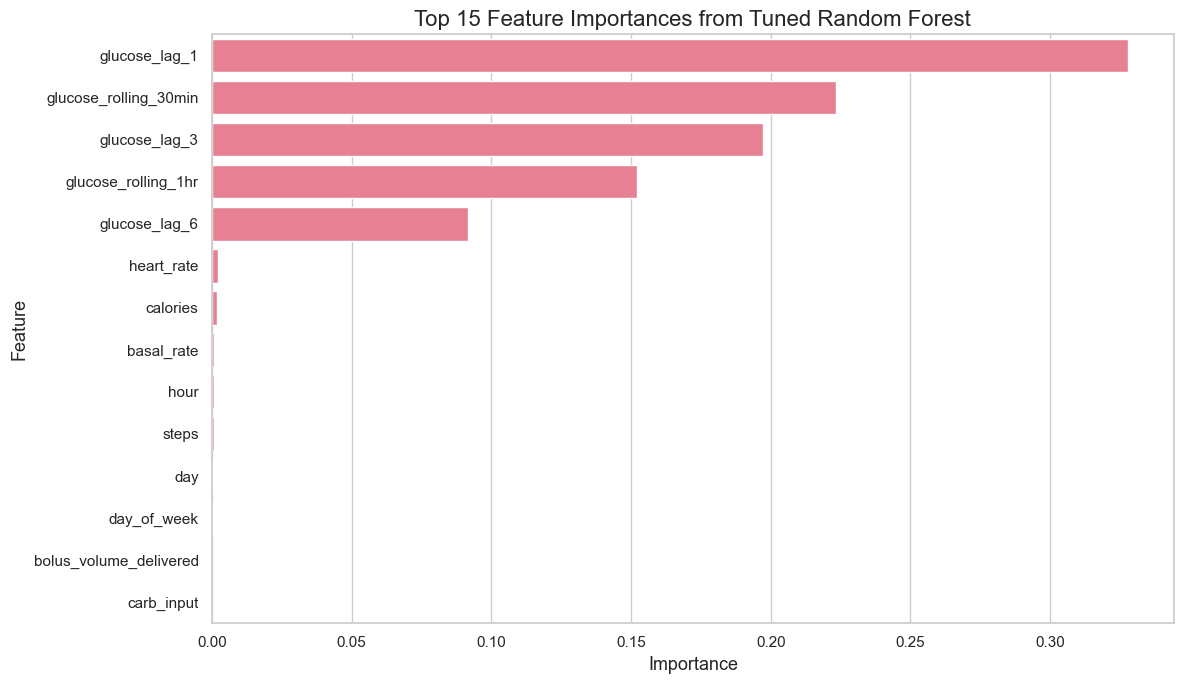

In [30]:
# Plot top 15 important features

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances from Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Why this step is needed

Feature importance helps explain which variables are most useful for predicting glucose.

### Consequences if skipped

The model becomes harder to interpret and explain in a project portfolio.

# 20. Feature Selection Improvement

In [31]:
# Feature selection using model-based importance

selector = SelectFromModel(
    final_tuned_model,
    threshold="median",
    prefit=True
)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()].tolist()

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", len(selected_features))
print("Selected features:")
print(selected_features)

Original number of features: 14
Selected number of features: 7
Selected features:
['calories', 'heart_rate', 'glucose_lag_1', 'glucose_lag_3', 'glucose_lag_6', 'glucose_rolling_30min', 'glucose_rolling_1hr']


### Why this step is needed

Feature selection removes weaker features and keeps stronger predictors.

### Consequences if skipped

The model may include noisy or unnecessary features, which can increase overfitting and reduce interpretability.

# 21. Train Tuned Model on Selected Features

In [32]:
# Create new Random Forest using best parameters

selected_feature_model = RandomForestRegressor(
    **final_tuned_model.get_params()
)

selected_feature_model.fit(X_train_selected, y_train)

selected_train_pred = selected_feature_model.predict(X_train_selected)
selected_test_pred = selected_feature_model.predict(X_test_selected)

selected_train_eval = evaluate_model(
    "Tuned Random Forest with Selected Features - Train",
    y_train,
    selected_train_pred
)

selected_test_eval = evaluate_model(
    "Tuned Random Forest with Selected Features - Test",
    y_test,
    selected_test_pred
)

selected_results_df = pd.DataFrame([
    selected_train_eval,
    selected_test_eval
])

selected_results_df

,model,MAE,RMSE,R2
0,Tuned Random Forest with Selected Features - T...,0.759631,1.465263,0.999341
1,Tuned Random Forest with Selected Features - Test,1.508096,3.504146,0.996229


### Why this step is needed

This checks whether using only important features improves or maintains performance.

### Consequences if skipped

We will not know whether the model can be simplified without losing predictive power.

# 22. Final Tuned Model Comparison

In [33]:
final_comparison = pd.concat(
    [
        comparison_results,
        selected_results_df
    ],
    ignore_index=True
)

final_comparison

,model,MAE,RMSE,R2
0,Baseline Random Forest - Train,0.543852,1.388946,0.999408
1,Baseline Random Forest - Test,1.478842,3.787735,0.995593
2,GridSearchCV Random Forest - Train,0.543852,1.388946,0.999408
3,GridSearchCV Random Forest - Test,1.478842,3.787735,0.995593
4,RandomizedSearchCV Random Forest - Train,0.924361,1.615871,0.999199
5,RandomizedSearchCV Random Forest - Test,1.731706,3.649768,0.995909
6,Tuned Random Forest with Selected Features - T...,0.759631,1.465263,0.999341
7,Tuned Random Forest with Selected Features - Test,1.508096,3.504146,0.996229


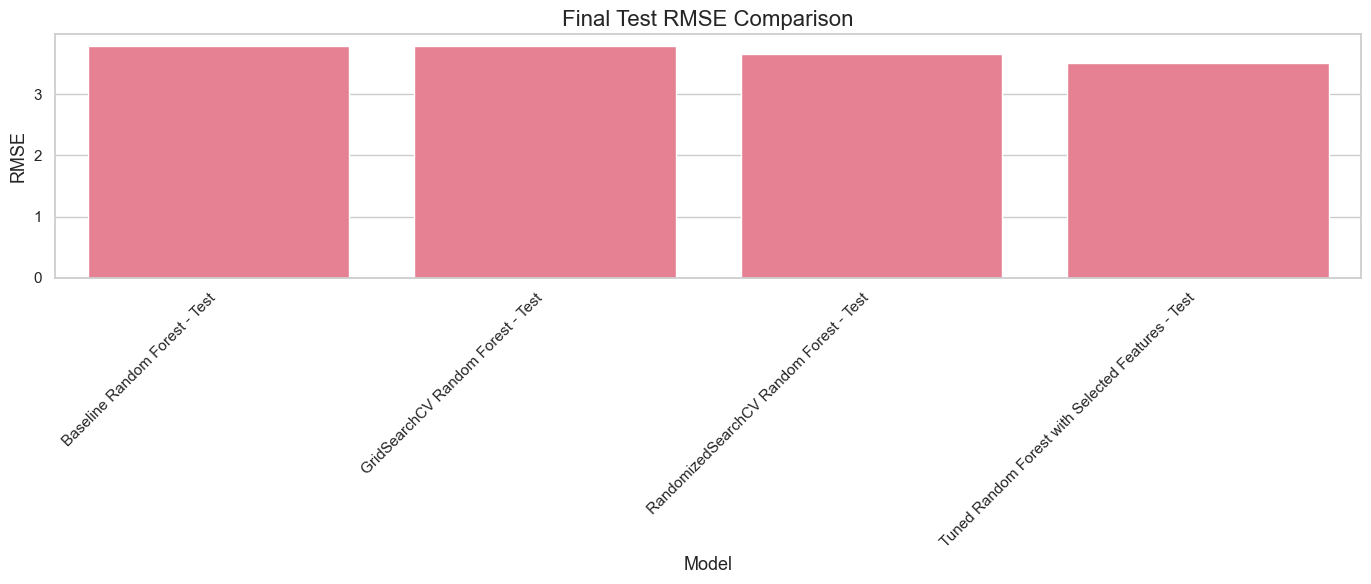

In [34]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=final_comparison[final_comparison["model"].str.contains("Test")],
    x="model",
    y="RMSE"
)

plt.title("Final Test RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

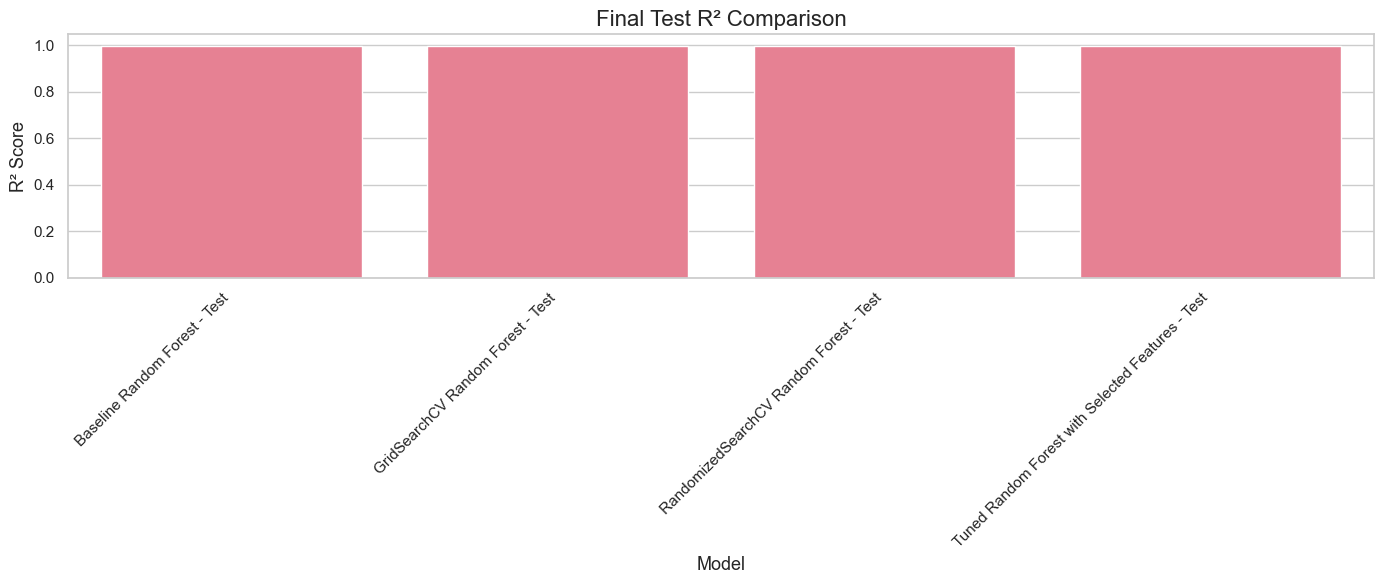

In [35]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=final_comparison[final_comparison["model"].str.contains("Test")],
    x="model",
    y="R2"
)

plt.title("Final Test R² Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Why this step is needed

This final comparison helps decide whether the full tuned model or selected-feature tuned model should be saved as the final optimized model.

### Consequences if skipped

The final model choice may not be clearly justified.

# 23. Final Model Selection

In [36]:
# Choose best final model from all test results

final_test_results = final_comparison[
    final_comparison["model"].str.contains("Test")
].copy()

final_best_row = final_test_results.sort_values("RMSE").iloc[0]

final_best_row

model    Tuned Random Forest with Selected Features - Test
MAE                                               1.508096
RMSE                                              3.504146
R2                                                0.996229
Name: 7, dtype: object

In [37]:
# Assign final optimized model and final feature set

if final_best_row["model"] == "Tuned Random Forest with Selected Features - Test":
    optimized_model = selected_feature_model
    optimized_features = selected_features
    X_test_final = X_test_selected
    y_pred_final = selected_test_pred
    final_model_label = "Tuned Random Forest with Selected Features"
else:
    optimized_model = final_tuned_model
    optimized_features = features
    X_test_final = X_test
    y_pred_final = final_tuned_model.predict(X_test)
    final_model_label = final_model_name

print("Final optimized model:", final_model_label)
print("Number of final features:", len(optimized_features))

Final optimized model: Tuned Random Forest with Selected Features
Number of final features: 7


### Why this step is needed

This step finalizes the best model and feature set for saving and future use.

### Consequences if skipped

The project may contain many models but no clear final optimized model.

# 24. Advanced Evaluation: Actual vs Predicted

In [38]:
# Actual vs predicted dataframe

final_predictions_df = pd.DataFrame({
    "actual_glucose": y_test,
    "predicted_glucose": y_pred_final
})

final_predictions_df["residual"] = (
    final_predictions_df["actual_glucose"] -
    final_predictions_df["predicted_glucose"]
)

final_predictions_df.head()

,actual_glucose,predicted_glucose,residual
52094,85.333333,85.343934,-0.010600
78767,121.000000,116.526660,4.473340
46712,302.000000,301.010600,0.989400
63929,91.000000,88.024835,2.975165
33067,213.666667,216.043834,-2.377167


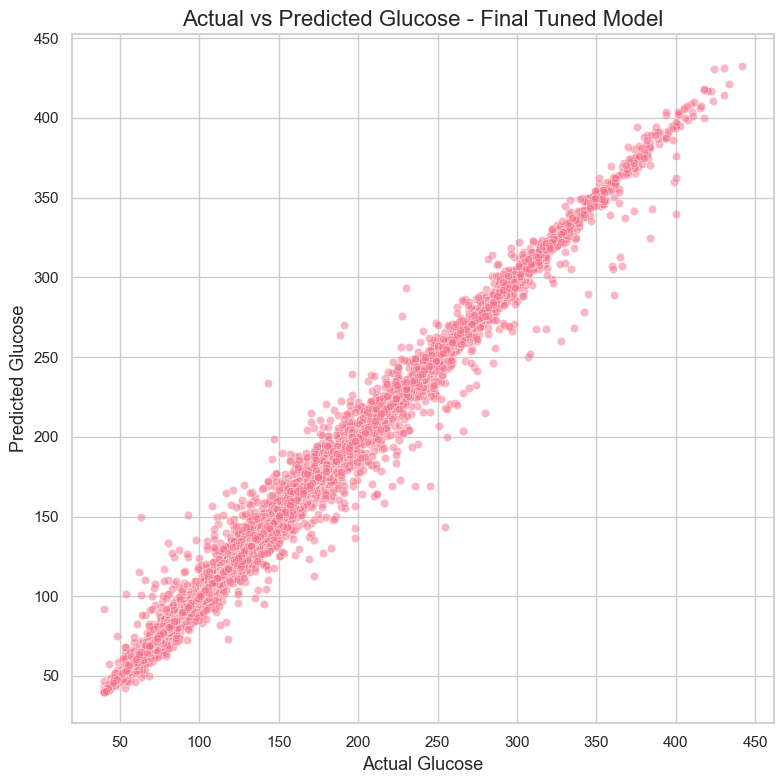

In [39]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=final_predictions_df,
    x="actual_glucose",
    y="predicted_glucose",
    alpha=0.5
)

plt.title("Actual vs Predicted Glucose - Final Tuned Model")
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.tight_layout()
plt.show()

### Why this step is needed

Actual vs predicted plots show how closely predictions match real glucose values.

### Consequences if skipped

We may miss patterns where the model performs poorly at very low or very high glucose values.

# 25. Advanced Evaluation: Residual Analysis

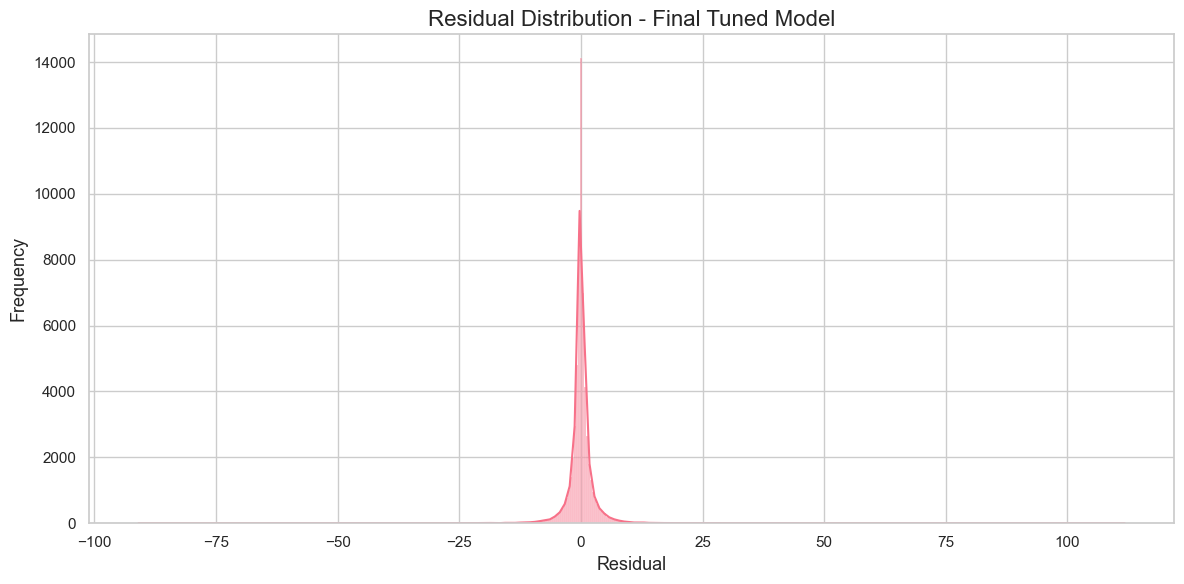

In [40]:
plt.figure(figsize=(12, 6))

sns.histplot(
    final_predictions_df["residual"],
    kde=True
)

plt.title("Residual Distribution - Final Tuned Model")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

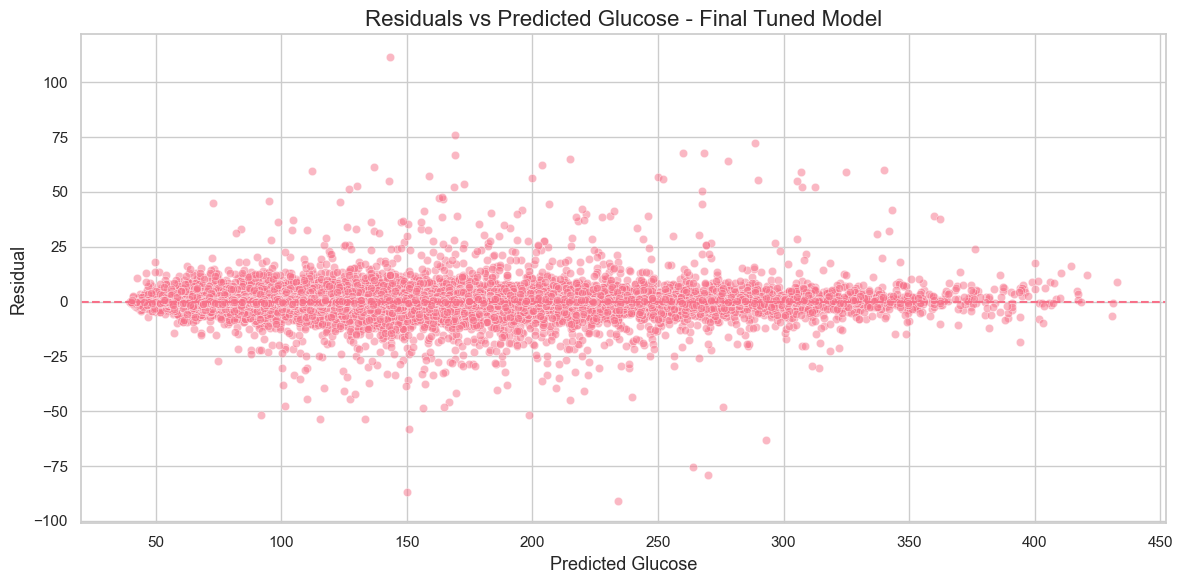

In [41]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=final_predictions_df,
    x="predicted_glucose",
    y="residual",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Glucose - Final Tuned Model")
plt.xlabel("Predicted Glucose")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

### Why this step is needed

Residual analysis helps identify bias, error patterns, and prediction weaknesses.

### Consequences if skipped

The model may appear strong by metrics but still have systematic prediction errors.

# 26. Error Category Analysis

In [42]:
# Create absolute error column

final_predictions_df["absolute_error"] = np.abs(
    final_predictions_df["actual_glucose"] -
    final_predictions_df["predicted_glucose"]
)

final_predictions_df["error_category"] = pd.cut(
    final_predictions_df["absolute_error"],
    bins=[0, 10, 20, 40, np.inf],
    labels=["Low Error", "Moderate Error", "High Error", "Very High Error"]
)

final_predictions_df["error_category"].value_counts()

error_category
Low Error          60785
Moderate Error       671
High Error           228
Very High Error       67
Name: count, dtype: int64

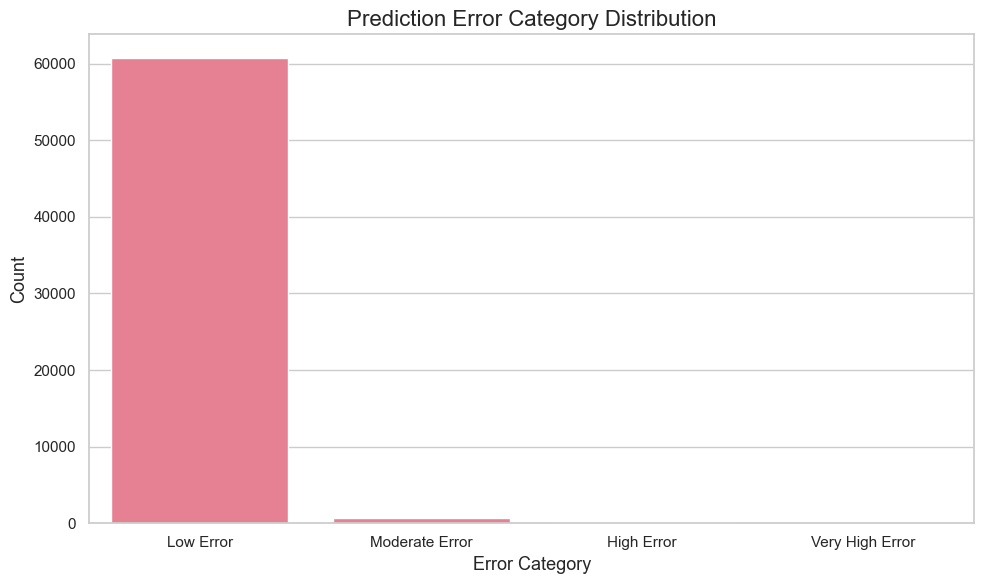

In [43]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=final_predictions_df,
    x="error_category"
)

plt.title("Prediction Error Category Distribution")
plt.xlabel("Error Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Why this step is needed

This shows how many predictions fall into low, moderate, high, or very high error ranges.

### Consequences if skipped

We only see average error and may miss how often large prediction mistakes happen.

# 27. SHAP / Interpretability Basics

In [44]:
# Optional SHAP installation note:
# If SHAP is not installed, run this in terminal:
# pip install shap

try:
    import shap
    shap_available = True
    print("SHAP is available.")
except ImportError:
    shap_available = False
    print("SHAP is not installed. Install it using: pip install shap")

SHAP is available.


In [45]:
X_shap = X_test[optimized_features].sample(
    n=100,
    random_state=42
)

explainer = shap.TreeExplainer(optimized_model)

shap_values = explainer.shap_values(X_shap)

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

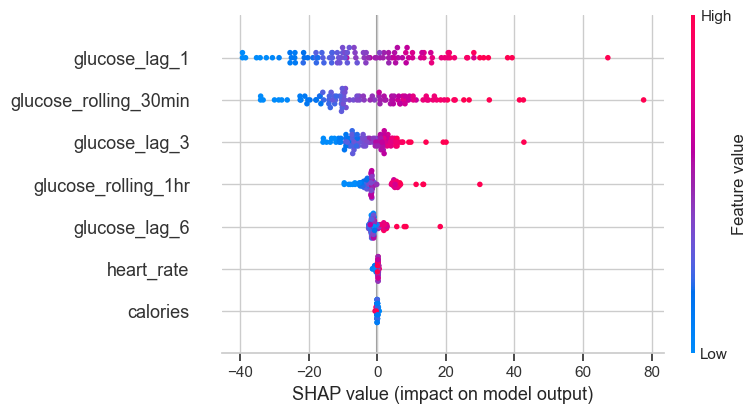

In [46]:
shap.summary_plot(
    shap_values,
    X_shap
)

### Why this step is needed

SHAP helps explain how each feature contributes to model predictions.

### Consequences if skipped

The model remains less interpretable, especially for stakeholders who want to understand why predictions are made.

# 28. Save Tuned Model Results

In [47]:
# Save final comparison results

tuned_results_path = os.path.join(REPORTS_DIR, "tuned_model_results.csv")

final_comparison.to_csv(
    tuned_results_path,
    index=False
)

print("Tuned model results saved to:", tuned_results_path)

Tuned model results saved to: c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports\tuned_model_results.csv


In [48]:
# Save final predictions

tuned_predictions_path = os.path.join(REPORTS_DIR, "tuned_model_predictions.csv")

final_predictions_df.to_csv(
    tuned_predictions_path,
    index=False
)

print("Tuned model predictions saved to:", tuned_predictions_path)

Tuned model predictions saved to: c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports\tuned_model_predictions.csv


In [49]:
# Save final optimized feature list

tuned_feature_list_path = os.path.join(REPORTS_DIR, "tuned_model_feature_list.csv")

pd.DataFrame({
    "feature_name": optimized_features
}).to_csv(
    tuned_feature_list_path,
    index=False
)

print("Tuned model feature list saved to:", tuned_feature_list_path)

Tuned model feature list saved to: c:\Projects\DataAnalysis\diabetes-glucose-analysis\reports\tuned_model_feature_list.csv


### Why this step is needed

Saving results makes the notebook reproducible and allows future notebooks to reuse outputs.

### Consequences if skipped

Results may be lost after restarting the notebook.

# 29. Save Final Optimized Model

In [50]:
# Save optimized model

optimized_model_path = os.path.join(MODELS_DIR, "final_tuned_random_forest_model.pkl")

with open(optimized_model_path, "wb") as file:
    pickle.dump(optimized_model, file)

print("Final optimized model saved to:", optimized_model_path)

Final optimized model saved to: c:\Projects\DataAnalysis\diabetes-glucose-analysis\models\final_tuned_random_forest_model.pkl


### Why this step is needed

Saving the trained model allows it to be reused later without retraining.

### Consequences if skipped

You would need to rerun the full tuning process every time, which can take a long time.

# Final Summary

## What was completed in this notebook

In this notebook, we improved the baseline glucose prediction model using hyperparameter tuning and model optimization.

## Main steps completed

- Loaded modeling-ready dataset
- Loaded baseline results
- Recreated baseline Random Forest comparison
- Applied cross-validation
- Tuned Random Forest using GridSearchCV
- Tuned Random Forest using RandomizedSearchCV
- Compared baseline and tuned models
- Analyzed overfitting
- Performed feature importance analysis
- Applied feature selection
- Evaluated final optimized model
- Performed residual analysis
- Added SHAP interpretability basics
- Saved tuned model results
- Saved tuned predictions
- Saved final tuned model

## Key interpretation

The tuned Random Forest model was compared against the baseline model using MAE, RMSE, and R².

The best final model was selected based on the lowest test RMSE and strongest generalization performance.

## Files created

- tuned_model_results.csv
- tuned_model_predictions.csv
- tuned_model_feature_list.csv
- final_tuned_random_forest_model.pkl

## Next step

The next notebook should focus on final model interpretation, business/project conclusions, and preparing the project for portfolio presentation.

Important Note About Feature Importance

Your tuned_model_feature_list.csv may only contain feature names.

If you want a proper feature importance chart, add this code at the end of Notebook 6.

In [52]:
%who

BASE_DIR	 DATA_DIR	 DecisionTreeRegressor	 GridSearchCV	 KFold	 LinearRegression	 MODELS_DIR	 REPORTS_DIR	 RandomForestRegressor	 
RandomizedSearchCV	 SelectFromModel	 X	 X_shap	 X_test	 X_test_final	 X_test_selected	 X_train	 X_train_selected	 
baseline_results	 baseline_results_path	 baseline_rf	 baseline_rf_test_pred	 baseline_rf_train_pred	 baseline_test_eval	 baseline_train_eval	 best_grid_rf	 best_model_row	 
best_random_rf	 comparison_results	 cross_val_score	 cv	 cv_rmse_scores	 cv_scores	 df	 evaluate_model	 explainer	 
feature_importance	 feature_list_df	 feature_list_path	 features	 file	 final_best_row	 final_comparison	 final_model_label	 final_model_name	 
final_predictions_df	 final_test_results	 final_tuned_model	 grid_results_df	 grid_rf	 grid_search	 grid_test_eval	 grid_test_pred	 grid_train_eval	 
grid_train_pred	 mean_absolute_error	 mean_squared_error	 modeling_data_path	 np	 optimized_features	 optimized_model	 optimized_model_path	 os	 
overfit_summary	 overfitt

In [53]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_tuned_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(10)

,feature,importance
9,glucose_lag_1,0.327931
12,glucose_rolling_30min,0.223430
10,glucose_lag_3,0.197195
13,glucose_rolling_1hr,0.152312
11,glucose_lag_6,0.091655
1,heart_rate,0.002251
0,calories,0.001871
3,basal_rate,0.000893
6,hour,0.000810
2,steps,0.000654
